prompt 1

In [ ]:
# ==========================================================
# CÉLULA 1 - Importação e carregamento da base
# ==========================================================

import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

arquivo = next(iter(uploaded))
df_original = pd.read_csv(arquivo)

df = df_original.copy()

print("Primeiras linhas:")
display(df.head())

print(f"Dimensões: {df.shape}")

print("\nTipos identificados pelo pandas:")
display(df.dtypes.rename("dtype"))

Saving Automobile_dataset.csv to Automobile_dataset.csv
Primeiras linhas:


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Dimensões: (205, 26)

Tipos identificados pelo pandas:


,dtype
symboling,int64
normalized_losses,object
make,object
fuel_type,object
aspiration,object
num_of_doors,object
body_style,object
drive_wheels,object
engine_location,object
wheel_base,float64


In [ ]:
# ==========================================================
# CÉLULA 2 - Classificação estatística das variáveis
# ==========================================================

qualitativa_ordinal = [
    "symboling"
]

qualitativa_nominal = [
    "make",
    "fuel_type",
    "aspiration",
    "body_style",
    "drive_wheels",
    "engine_location",
    "engine_type",
    "fuel_system"
]

quantitativa_discreta = [
    "num_of_doors",
    "num_of_cylinders"
]

classificacao = {}

for v in qualitativa_ordinal:
    classificacao[v] = "Qualitativa ordinal"

for v in qualitativa_nominal:
    classificacao[v] = "Qualitativa nominal"

for v in quantitativa_discreta:
    classificacao[v] = "Quantitativa discreta"

for v in df.columns:
    if v not in classificacao:
        classificacao[v] = "Quantitativa contínua"

tabela_variaveis = pd.DataFrame({
    "Variável": df.columns,
    "Tipo inicial (pandas)": [str(df[c].dtype) for c in df.columns],
    "Classificação estatística": [classificacao[c] for c in df.columns],
    "Valores distintos": [df[c].nunique(dropna=True) for c in df.columns],
    "Exemplos": [
        ", ".join(df[c].dropna().astype(str).unique()[:5])
        for c in df.columns
    ]
})

display(tabela_variaveis)

,Variável,Tipo inicial (pandas),Classificação estatística,Valores distintos,Exemplos
0,symboling,int64,Qualitativa ordinal,6,"3, 1, 2, 0, -1"
1,normalized_losses,object,Quantitativa contínua,52,"?, 164, 158, 192, 188"
2,make,object,Qualitativa nominal,22,"alfa-romero, audi, bmw, chevrolet, dodge"
3,fuel_type,object,Qualitativa nominal,2,"gas, diesel"
4,aspiration,object,Qualitativa nominal,2,"std, turbo"
5,num_of_doors,object,Quantitativa discreta,3,"two, four, ?"
6,body_style,object,Qualitativa nominal,5,"convertible, hatchback, sedan, wagon, hardtop"
7,drive_wheels,object,Qualitativa nominal,3,"rwd, fwd, 4wd"
8,engine_location,object,Qualitativa nominal,2,"front, rear"
9,wheel_base,float64,Quantitativa contínua,53,"88.6, 94.5, 99.8, 99.4, 105.8"


In [ ]:
# ==========================================================
# CÉLULA 3 - Tratamento dos dados inválidos
# ==========================================================

# Remove espaços das colunas textuais
colunas_texto = df.select_dtypes(include="object").columns

for c in colunas_texto:
    df[c] = df[c].str.strip()

# Padroniza valores inválidos
df.replace(
    ["?", "", "NA", "N/A", "null", "None"],
    np.nan,
    inplace=True
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Conversão explícita das variáveis discretas
mapa_portas = {
    "two": 2,
    "four": 4
}

mapa_cilindros = {
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}

df["num_of_doors"] = df["num_of_doors"].map(mapa_portas)
df["num_of_cylinders"] = df["num_of_cylinders"].map(mapa_cilindros)

# Conversão das variáveis quantitativas
variaveis_quantitativas = [
    c for c, t in classificacao.items()
    if t in ["Quantitativa discreta", "Quantitativa contínua"]
]

for c in variaveis_quantitativas:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Resumo dos valores inválidos
invalidos = df.isna().sum()

tabela_invalidos = pd.DataFrame({
    "Valores inválidos": invalidos,
    "% inválidos": (invalidos / len(df) * 100).round(2)
})

display(tabela_invalidos)

linhas_invalidas = df.isna().any(axis=1).sum()

print(f"Total de linhas com pelo menos um valor inválido: {linhas_invalidas}")

,Valores inválidos,% inválidos
symboling,0,0.00
normalized_losses,41,20.00
make,0,0.00
fuel_type,0,0.00
aspiration,0,0.00
num_of_doors,2,0.98
body_style,0,0.00
drive_wheels,0,0.00
engine_location,0,0.00
wheel_base,0,0.00


Total de linhas com pelo menos um valor inválido: 46


In [ ]:
# ==========================================================
# CÉLULA 4 - Limpeza e tipos finais
# ==========================================================

linhas_antes = len(df)

df_clean = df.dropna().copy()

linhas_depois = len(df_clean)
linhas_removidas = linhas_antes - linhas_depois

# Symboling como categoria ordenada
categorias_symboling = [-2, -1, 0, 1, 2, 3]

df_clean["symboling"] = pd.Categorical(
    df_clean["symboling"].astype(int),
    categories=categorias_symboling,
    ordered=True
)

# Variáveis qualitativas nominais
for c in qualitativa_nominal:
    df_clean[c] = df_clean[c].astype("category")

print(f"Linhas antes da limpeza : {linhas_antes}")
print(f"Linhas após a limpeza   : {linhas_depois}")
print(f"Linhas removidas        : {linhas_removidas}")
print(f"Percentual removido     : {100 * linhas_removidas / linhas_antes:.2f}%")

print("\nPrimeiras linhas do conjunto limpo:")
display(df_clean.head())

print("\nTipos finais:")
display(df_clean.dtypes.rename("dtype"))

print("\nPossui valores ausentes?")
print(df_clean.isna().sum().sum() == 0)

Linhas antes da limpeza : 205
Linhas após a limpeza   : 159
Linhas removidas        : 46
Percentual removido     : 22.44%

Primeiras linhas do conjunto limpo:


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500.0,18,22,17450.0
6,1,158.0,audi,gas,std,4.0,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110.0,5500.0,19,25,17710.0
8,1,158.0,audi,gas,turbo,4.0,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140.0,5500.0,17,20,23875.0
10,2,192.0,bmw,gas,std,2.0,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.8,8.8,101.0,5800.0,23,29,16430.0



Tipos finais:


,dtype
symboling,category
normalized_losses,float64
make,category
fuel_type,category
aspiration,category
num_of_doors,float64
body_style,category
drive_wheels,category
engine_location,category
wheel_base,float64



Possui valores ausentes?
True


prompt 2

In [5]:
# ==========================================================
# CÉLULA 1 - Configurações gerais
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cm = 1 / 2.54

plt.rcParams["font.family"] = "serif"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.titlecolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["legend.labelcolor"] = "black"

cmap = plt.cm.viridis

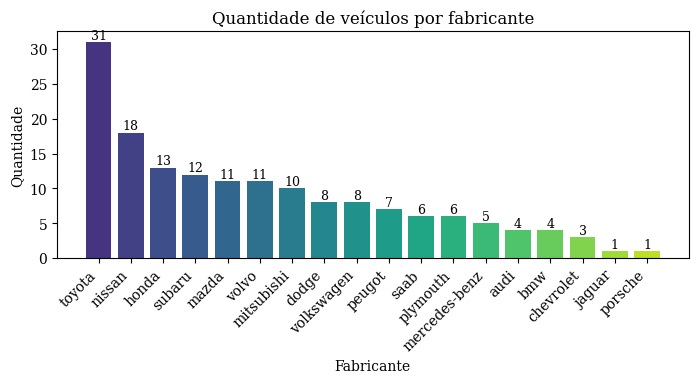

In [6]:
# ==========================================================
# CÉLULA 2 - Gráfico 1
# Quantidade de veículos por fabricante
# ==========================================================

contagem = df_clean["make"].value_counts()

cores = cmap(np.linspace(0.15, 0.90, len(contagem)))

plt.figure(figsize=(18*cm, 10*cm))

barras = plt.bar(
    contagem.index,
    contagem.values,
    color=cores
)

for barra in barras:
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        f"{int(barra.get_height())}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Quantidade de veículos por fabricante")
plt.xlabel("Fabricante")
plt.ylabel("Quantidade")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_609/3742952954.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("make")[["city_mpg", "highway_mpg"]]


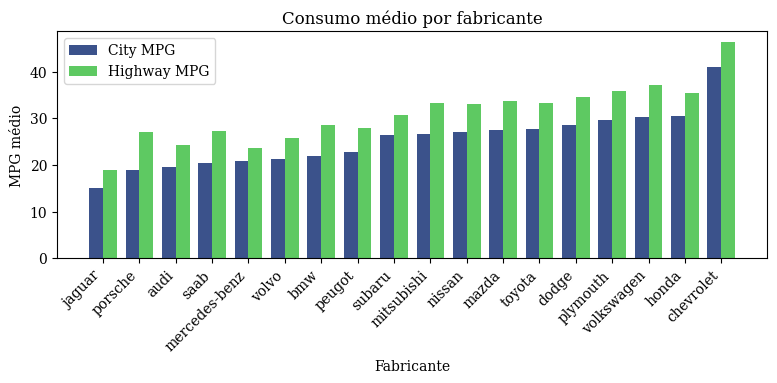

In [7]:
# ==========================================================
# CÉLULA 3 - Gráfico 2
# Consumo médio por fabricante
# ==========================================================

consumo = (
    df_clean
    .groupby("make")[["city_mpg", "highway_mpg"]]
    .mean()
    .sort_values("city_mpg")
)

x = np.arange(len(consumo))
largura = 0.38

cores = cmap([0.25, 0.75])

plt.figure(figsize=(20*cm, 10*cm))

plt.bar(
    x - largura/2,
    consumo["city_mpg"],
    largura,
    color=cores[0],
    label="City MPG"
)

plt.bar(
    x + largura/2,
    consumo["highway_mpg"],
    largura,
    color=cores[1],
    label="Highway MPG"
)

plt.xticks(x, consumo.index, rotation=45, ha="right")

plt.title("Consumo médio por fabricante")
plt.xlabel("Fabricante")
plt.ylabel("MPG médio")

plt.legend()

plt.tight_layout()
plt.show()

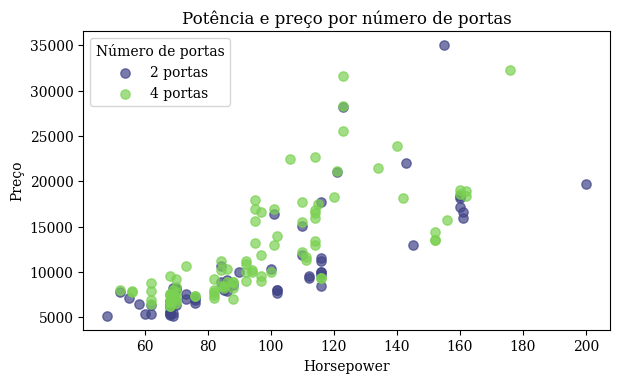

In [8]:
# ==========================================================
# CÉLULA 4 - Gráfico 3
# Potência e preço por número de portas
# ==========================================================

categorias = sorted(df_clean["num_of_doors"].unique())

cores = cmap(np.linspace(0.2, 0.8, len(categorias)))

plt.figure(figsize=(16*cm, 10*cm))

for cor, portas in zip(cores, categorias):

    dados = df_clean[df_clean["num_of_doors"] == portas]

    plt.scatter(
        dados["horsepower"],
        dados["price"],
        s=45,
        alpha=0.7,
        color=cor,
        label=f"{int(portas)} portas"
    )

plt.title("Potência e preço por número de portas")
plt.xlabel("Horsepower")
plt.ylabel("Preço")

plt.legend(title="Número de portas")

plt.tight_layout()
plt.show()

prompt 3

In [9]:
# ==========================================================
# CÉLULA 1 - Importações e seleção das variáveis categóricas
# ==========================================================

import pandas as pd
from scipy.stats import chi2_contingency
from itertools import combinations

variaveis_categoricas = tabela_variaveis.loc[
    tabela_variaveis["Classificação estatística"].isin(
        ["Qualitativa nominal", "Qualitativa ordinal"]
    ),
    "Variável"
].tolist()

print("Variáveis categóricas selecionadas:")
print(variaveis_categoricas)

Variáveis categóricas selecionadas:
['symboling', 'make', 'fuel_type', 'aspiration', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']


In [10]:
# ==========================================================
# CÉLULA 2 - Testes de associação
# ==========================================================

alpha = 0.05

resultados = []

for var1, var2 in combinations(variaveis_categoricas, 2):

    tabela = pd.crosstab(df_clean[var1], df_clean[var2])

    qui2, p_valor, gl, _ = chi2_contingency(tabela)

    significativo = "Sim" if p_valor < alpha else "Não"

    conclusao = (
        "Existe associação estatisticamente significativa ao nível de 5%."
        if p_valor < alpha
        else "Não foram encontradas evidências estatísticas suficientes de associação ao nível de 5%."
    )

    resultados.append({
        "variavel_1": var1,
        "variavel_2": var2,
        "qui_quadrado": round(qui2, 4),
        "graus_liberdade": gl,
        "p_valor": round(p_valor, 6),
        "significativo_5_porcento": significativo,
        "conclusao": conclusao
    })

resultados_associacao = (
    pd.DataFrame(resultados)
    .sort_values("p_valor")
    .reset_index(drop=True)
)

display(resultados_associacao)

,variavel_1,variavel_2,qui_quadrado,graus_liberdade,p_valor,significativo_5_porcento,conclusao
0,symboling,make,245.5183,85,0.000000,Sim,Existe associação estatisticamente significati...
1,symboling,body_style,73.8666,20,0.000000,Sim,Existe associação estatisticamente significati...
2,make,engine_type,384.0487,68,0.000000,Sim,Existe associação estatisticamente significati...
3,make,drive_wheels,147.6265,34,0.000000,Sim,Existe associação estatisticamente significati...
4,make,fuel_system,324.8646,85,0.000000,Sim,Existe associação estatisticamente significati...
5,drive_wheels,engine_type,66.4554,8,0.000000,Sim,Existe associação estatisticamente significati...
6,aspiration,fuel_system,60.5195,5,0.000000,Sim,Existe associação estatisticamente significati...
7,fuel_type,fuel_system,159.0000,5,0.000000,Sim,Existe associação estatisticamente significati...
8,drive_wheels,fuel_system,57.4989,10,0.000000,Sim,Existe associação estatisticamente significati...
9,fuel_type,aspiration,25.2420,1,0.000001,Sim,Existe associação estatisticamente significati...


In [11]:
# ==========================================================
# CÉLULA 3 - Resultados separados
# ==========================================================

print("Pares com associação estatisticamente significativa (5%)")
display(
    resultados_associacao[
        resultados_associacao["significativo_5_porcento"] == "Sim"
    ]
)

print("Pares sem associação estatisticamente significativa (5%)")
display(
    resultados_associacao[
        resultados_associacao["significativo_5_porcento"] == "Não"
    ]
)

Pares com associação estatisticamente significativa (5%)


,variavel_1,variavel_2,qui_quadrado,graus_liberdade,p_valor,significativo_5_porcento,conclusao
0,symboling,make,245.5183,85,0.000000,Sim,Existe associação estatisticamente significati...
1,symboling,body_style,73.8666,20,0.000000,Sim,Existe associação estatisticamente significati...
2,make,engine_type,384.0487,68,0.000000,Sim,Existe associação estatisticamente significati...
3,make,drive_wheels,147.6265,34,0.000000,Sim,Existe associação estatisticamente significati...
4,make,fuel_system,324.8646,85,0.000000,Sim,Existe associação estatisticamente significati...
5,drive_wheels,engine_type,66.4554,8,0.000000,Sim,Existe associação estatisticamente significati...
6,aspiration,fuel_system,60.5195,5,0.000000,Sim,Existe associação estatisticamente significati...
7,fuel_type,fuel_system,159.0000,5,0.000000,Sim,Existe associação estatisticamente significati...
8,drive_wheels,fuel_system,57.4989,10,0.000000,Sim,Existe associação estatisticamente significati...
9,fuel_type,aspiration,25.2420,1,0.000001,Sim,Existe associação estatisticamente significati...


Pares sem associação estatisticamente significativa (5%)


,variavel_1,variavel_2,qui_quadrado,graus_liberdade,p_valor,significativo_5_porcento,conclusao
20,symboling,fuel_type,10.7326,5,0.056947,Não,Não foram encontradas evidências estatísticas ...
21,fuel_type,drive_wheels,5.1835,2,0.074889,Não,Não foram encontradas evidências estatísticas ...
22,fuel_type,body_style,8.0100,4,0.091213,Não,Não foram encontradas evidências estatísticas ...
23,make,body_style,83.5625,68,0.096697,Não,Não foram encontradas evidências estatísticas ...
24,aspiration,engine_type,7.1472,4,0.128313,Não,Não foram encontradas evidências estatísticas ...
25,body_style,engine_type,22.4554,16,0.129086,Não,Não foram encontradas evidências estatísticas ...
26,body_style,fuel_system,24.9001,20,0.205278,Não,Não foram encontradas evidências estatísticas ...
27,aspiration,body_style,1.8444,4,0.764353,Não,Não foram encontradas evidências estatísticas ...
28,aspiration,engine_location,0.0000,0,1.000000,Não,Não foram encontradas evidências estatísticas ...
29,fuel_type,engine_location,0.0000,0,1.000000,Não,Não foram encontradas evidências estatísticas ...


prompt 4

In [12]:
# ==========================================================
# CÉLULA 1 - Importações e seleção das variáveis quantitativas
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import combinations

variaveis_quantitativas = tabela_variaveis.loc[
    tabela_variaveis["Classificação estatística"].isin(
        ["Quantitativa discreta", "Quantitativa contínua"]
    ),
    "Variável"
].tolist()

print("Variáveis quantitativas selecionadas:")
print(variaveis_quantitativas)

Variáveis quantitativas selecionadas:
['normalized_losses', 'num_of_doors', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'num_of_cylinders', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']


In [13]:
# ==========================================================
# CÉLULA 2 - Matriz de correlação
# ==========================================================

matriz_correlacao = df_clean[variaveis_quantitativas].corr(method="pearson")

display(matriz_correlacao)

,normalized_losses,num_of_doors,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
normalized_losses,1.000000,-0.393539,-0.060086,0.035541,0.109726,-0.413702,0.125858,0.268157,0.207820,-0.031558,0.063330,-0.127259,0.290511,0.237697,-0.235523,-0.188564,0.202761
num_of_doors,-0.393539,1.000000,0.427991,0.412630,0.246905,0.468731,0.259201,-0.013527,0.085100,0.214539,-0.028945,0.115414,0.029959,-0.168896,-0.165831,-0.160870,0.162152
wheel_base,-0.060086,0.427991,1.000000,0.871534,0.814991,0.555767,0.810181,0.312733,0.649206,0.578159,0.167449,0.291431,0.516948,-0.289234,-0.580657,-0.611750,0.734419
length,0.035541,0.412630,0.871534,1.000000,0.838338,0.499251,0.871291,0.389477,0.725953,0.646318,0.121073,0.184814,0.672063,-0.234074,-0.724544,-0.724599,0.760952
width,0.109726,0.246905,0.814991,0.838338,1.000000,0.292706,0.870595,0.507360,0.779253,0.572554,0.196619,0.258752,0.681872,-0.232216,-0.666684,-0.693339,0.843371
height,-0.413702,0.468731,0.555767,0.499251,0.292706,1.000000,0.367052,-0.058612,0.111083,0.254836,-0.091313,0.233308,0.034317,-0.245864,-0.199737,-0.226136,0.244836
curb_weight,0.125858,0.259201,0.810181,0.871291,0.870595,0.367052,1.000000,0.595873,0.888626,0.645792,0.173844,0.224724,0.790095,-0.259988,-0.762155,-0.789338,0.893639
num_of_cylinders,0.268157,-0.013527,0.312733,0.389477,0.507360,-0.058612,0.595873,1.000000,0.770809,0.134820,0.132264,0.061637,0.618514,-0.118165,-0.484712,-0.519366,0.641578
engine_size,0.207820,0.085100,0.649206,0.725953,0.779253,0.111083,0.888626,0.770809,1.000000,0.595737,0.299683,0.141097,0.812073,-0.284686,-0.699139,-0.714095,0.841496
bore,-0.031558,0.214539,0.578159,0.646318,0.572554,0.254836,0.645792,0.134820,0.595737,1.000000,-0.102581,0.015119,0.560239,-0.312269,-0.590440,-0.590850,0.533890


In [14]:
# ==========================================================
# CÉLULA 3 - Correlação entre todos os pares
# ==========================================================

alpha = 0.05

resultados = []

for var1, var2 in combinations(variaveis_quantitativas, 2):

    r, p = pearsonr(df_clean[var1], df_clean[var2])

    if np.isclose(r, -1):
        classificacao = "Perfeitamente negativa"

    elif -1 < r < -0.30:
        classificacao = "Média negativa"

    elif -0.30 <= r <= 0.30:
        classificacao = "Nula ou muito fraca"

    elif 0.30 < r < 1:
        classificacao = "Média positiva"

    elif np.isclose(r, 1):
        classificacao = "Perfeitamente positiva"

    else:
        classificacao = "Nula ou muito fraca"

    resultados.append({
        "variavel_1": var1,
        "variavel_2": var2,
        "coeficiente_pearson": round(r, 4),
        "p_valor": round(p, 6),
        "classificacao": classificacao,
        "significativo_5_porcento": "Sim" if p < alpha else "Não"
    })

resultados_correlacao = (
    pd.DataFrame(resultados)
    .sort_values(
        by="coeficiente_pearson",
        key=lambda x: np.abs(x),
        ascending=False
    )
    .reset_index(drop=True)
)

display(resultados_correlacao)

,variavel_1,variavel_2,coeficiente_pearson,p_valor,classificacao,significativo_5_porcento
0,city_mpg,highway_mpg,0.9720,0.000000,Média positiva,Sim
1,curb_weight,price,0.8936,0.000000,Média positiva,Sim
2,curb_weight,engine_size,0.8886,0.000000,Média positiva,Sim
3,wheel_base,length,0.8715,0.000000,Média positiva,Sim
4,length,curb_weight,0.8713,0.000000,Média positiva,Sim
...,...,...,...,...,...,...
131,stroke,city_mpg,-0.0201,0.801880,Nula ou muito fraca,Não
132,bore,compression_ratio,0.0151,0.849975,Nula ou muito fraca,Não
133,num_of_doors,num_of_cylinders,-0.0135,0.865619,Nula ou muito fraca,Não
134,stroke,highway_mpg,-0.0129,0.871451,Nula ou muito fraca,Não


In [15]:
# ==========================================================
# CÉLULA 4 - Resultados por classificação
# ==========================================================

categorias = [
    "Perfeitamente negativa",
    "Média negativa",
    "Nula ou muito fraca",
    "Média positiva",
    "Perfeitamente positiva"
]

for categoria in categorias:

    print(f"\n{categoria}")

    display(
        resultados_correlacao[
            resultados_correlacao["classificacao"] == categoria
        ]
    )


Perfeitamente negativa


,variavel_1,variavel_2,coeficiente_pearson,p_valor,classificacao,significativo_5_porcento



Média negativa


,variavel_1,variavel_2,coeficiente_pearson,p_valor,classificacao,significativo_5_porcento
9,horsepower,city_mpg,-0.8372,0.000000,Média negativa,Sim
10,horsepower,highway_mpg,-0.8279,0.000000,Média negativa,Sim
15,curb_weight,highway_mpg,-0.7893,0.000000,Média negativa,Sim
18,curb_weight,city_mpg,-0.7622,0.000000,Média negativa,Sim
23,length,highway_mpg,-0.7246,0.000000,Média negativa,Sim
24,length,city_mpg,-0.7245,0.000000,Média negativa,Sim
25,highway_mpg,price,-0.7201,0.000000,Média negativa,Sim
26,engine_size,highway_mpg,-0.7141,0.000000,Média negativa,Sim
27,engine_size,city_mpg,-0.6991,0.000000,Média negativa,Sim
28,width,highway_mpg,-0.6933,0.000000,Média negativa,Sim



Nula ou muito fraca


,variavel_1,variavel_2,coeficiente_pearson,p_valor,classificacao,significativo_5_porcento
64,engine_size,stroke,0.2997,0.000124,Nula ou muito fraca,Sim
65,width,height,0.2927,0.000181,Nula ou muito fraca,Sim
66,wheel_base,compression_ratio,0.2914,0.000194,Nula ou muito fraca,Sim
67,normalized_losses,horsepower,0.2905,0.000203,Nula ou muito fraca,Sim
68,wheel_base,peak_rpm,-0.2892,0.000218,Nula ou muito fraca,Sim
...,...,...,...,...,...,...
131,stroke,city_mpg,-0.0201,0.801880,Nula ou muito fraca,Não
132,bore,compression_ratio,0.0151,0.849975,Nula ou muito fraca,Não
133,num_of_doors,num_of_cylinders,-0.0135,0.865619,Nula ou muito fraca,Não
134,stroke,highway_mpg,-0.0129,0.871451,Nula ou muito fraca,Não



Média positiva


,variavel_1,variavel_2,coeficiente_pearson,p_valor,classificacao,significativo_5_porcento
0,city_mpg,highway_mpg,0.9720,0.000000,Média positiva,Sim
1,curb_weight,price,0.8936,0.000000,Média positiva,Sim
2,curb_weight,engine_size,0.8886,0.000000,Média positiva,Sim
3,wheel_base,length,0.8715,0.000000,Média positiva,Sim
4,length,curb_weight,0.8713,0.000000,Média positiva,Sim
5,width,curb_weight,0.8706,0.000000,Média positiva,Sim
6,width,price,0.8434,0.000000,Média positiva,Sim
7,engine_size,price,0.8415,0.000000,Média positiva,Sim
8,length,width,0.8383,0.000000,Média positiva,Sim
11,wheel_base,width,0.8150,0.000000,Média positiva,Sim



Perfeitamente positiva


,variavel_1,variavel_2,coeficiente_pearson,p_valor,classificacao,significativo_5_porcento


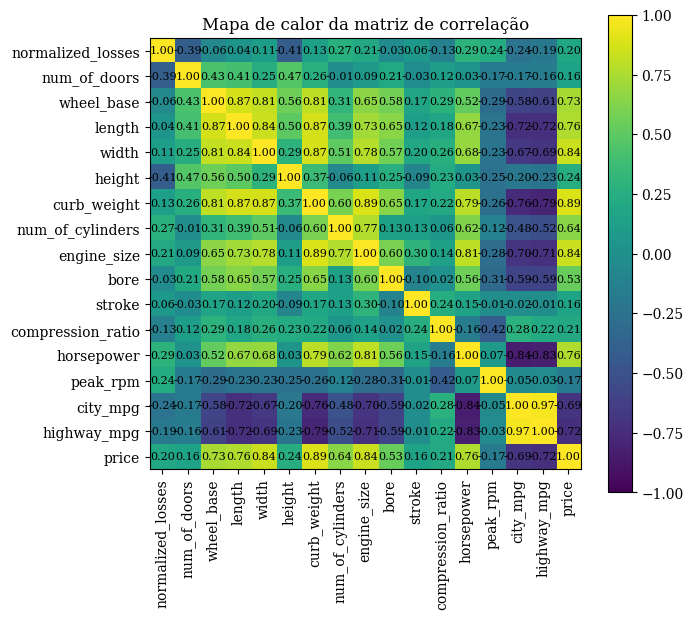

In [16]:
# ==========================================================
# CÉLULA 5 - Mapa de calor da correlação
# ==========================================================

cm = 1 / 2.54

plt.rcParams["font.family"] = "serif"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["axes.titlecolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

fig, ax = plt.subplots(figsize=(18*cm, 16*cm))

imagem = ax.imshow(
    matriz_correlacao,
    cmap="viridis",
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(variaveis_quantitativas)))
ax.set_yticks(np.arange(len(variaveis_quantitativas)))

ax.set_xticklabels(variaveis_quantitativas, rotation=90)
ax.set_yticklabels(variaveis_quantitativas)

for i in range(len(variaveis_quantitativas)):
    for j in range(len(variaveis_quantitativas)):
        ax.text(
            j,
            i,
            f"{matriz_correlacao.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Mapa de calor da matriz de correlação")

plt.colorbar(imagem)

plt.tight_layout()
plt.show()